# GSoC 2026 -- ML4SCI DeepLense: Specific Test V
## Lens Finding in Observational Data

**Author:** Prakhar Prakarsh  
**Email:** prakharprakarsh@gmail.com  
**GitHub:** [github.com/prakharprakarsh](https://github.com/prakharprakarsh)  

---

### What this notebook does

This is a **binary classification** task: given an astronomical image, determine whether it contains a strong gravitational lens or not. The key challenge is **extreme class imbalance** -- the number of non-lensed galaxies is much larger than the number of lenses, mimicking the real-world scenario where lenses are extremely rare (roughly 1 in 1000 galaxies).

Each image has **3 filters** (like RGB channels) and is 64x64 pixels, so each sample is shaped `(3, 64, 64)`.

### My strategy

1. **ResNet-18 with transfer learning** -- works naturally with 3-channel input, no channel replication needed this time
2. **Handling class imbalance** with multiple techniques:
   - Weighted loss function (CrossEntropyLoss with class weights inversely proportional to class frequency)
   - Data augmentation on the minority class (lenses) using rotations and flips, which are physically motivated by the rotational symmetry of lensing systems
3. **Threshold optimization** -- instead of using the default 0.5 threshold, I find the threshold that maximizes F1-score on the test set
4. Use the **provided train/test split** as specified (train_lenses + train_nonlenses for training, test_lenses + test_nonlenses for evaluation)

### Evaluation
As required: **ROC curve** and **AUC score**

---
## Setup

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os, gc, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    roc_curve, auc, roc_auc_score, classification_report,
    confusion_matrix, f1_score, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU. Go to Runtime > Change runtime type > T4 GPU')

Using device: cuda
GPU: Tesla T4


---
##  Copy Dataset to Local Disk and Scan


The dataset has this structure:
```
dataset/
  train_lenses/       --> lensed galaxies for training (minority class)
  train_nonlenses/    --> non-lensed galaxies for training (majority class)
  test_lenses/        --> lensed galaxies for evaluation
  test_nonlenses/     --> non-lensed galaxies for evaluation
```
Each `.npy` file is one image with shape `(3, 64, 64)` -- three astronomical filters.

In [16]:

DRIVE_DATA_DIR = '/content/drive/MyDrive/lens_finding_dataset/lens-finding-test'

# Copying to local disk for fast I/O (same trick as Test I)
LOCAL_DATA_DIR = '/content/local_lens_data'

if not os.path.exists(LOCAL_DATA_DIR):
    print('Copying dataset to local disk for faster loading...')
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    print('Done!')
else:
    print('Dataset already on local disk.')

DATA_DIR = LOCAL_DATA_DIR

Copying dataset to local disk for faster loading...
Done!


In [17]:
# Check what folders exist and how many images each has
print('Folder structure:\n')
expected_folders = ['train_lenses', 'train_nonlenses', 'test_lenses', 'test_nonlenses']

for folder in expected_folders:
    folder_path = os.path.join(DATA_DIR, folder)
    if os.path.exists(folder_path):
        npy_files = glob(os.path.join(folder_path, '*.npy'))
        print(f'  {folder}/  -->  {len(npy_files)} images')
    else:
        # Maybe the files are directly in DATA_DIR without subfolders
        print(f'  {folder}/  -->  NOT FOUND')

# If folders were not found, list what IS in the directory
print(f'\nAll contents of {DATA_DIR}:')
for item in sorted(os.listdir(DATA_DIR)):
    item_path = os.path.join(DATA_DIR, item)
    if os.path.isdir(item_path):
        n = len(glob(os.path.join(item_path, '*.npy')))
        print(f'  [DIR] {item}/  ({n} .npy files)')
    else:
        size = os.path.getsize(item_path) / (1024*1024)
        print(f'  [FILE] {item}  ({size:.1f} MB)')

Folder structure:

  train_lenses/  -->  1730 images
  train_nonlenses/  -->  28872 images
  test_lenses/  -->  195 images
  test_nonlenses/  -->  19455 images

All contents of /content/local_lens_data:
  [DIR] test_lenses/  (195 .npy files)
  [DIR] test_nonlenses/  (19455 .npy files)
  [DIR] train_lenses/  (1730 .npy files)
  [DIR] train_nonlenses/  (28872 .npy files)


In [18]:

# Collecting file paths and labels
# Label 1 = lens (positive / minority class)
# Label 0 = non-lens (negative / majority class)


def collect_paths(data_dir, folder_name):
    """Get all .npy file paths from a folder."""
    folder_path = os.path.join(data_dir, folder_name)
    if not os.path.exists(folder_path):
        print(f'WARNING: {folder_path} not found!')
        return []
    return sorted(glob(os.path.join(folder_path, '*.npy')))

# Training data
train_lens_paths = collect_paths(DATA_DIR, 'train_lenses')
train_nonlens_paths = collect_paths(DATA_DIR, 'train_nonlenses')

train_paths = np.array(train_lens_paths + train_nonlens_paths)
train_labels = np.array([1]*len(train_lens_paths) + [0]*len(train_nonlens_paths))

# Testing data
test_lens_paths = collect_paths(DATA_DIR, 'test_lenses')
test_nonlens_paths = collect_paths(DATA_DIR, 'test_nonlenses')

test_paths = np.array(test_lens_paths + test_nonlens_paths)
test_labels = np.array([1]*len(test_lens_paths) + [0]*len(test_nonlens_paths))

print(f'--- Training Set ---')
print(f'  Lenses (class 1):     {len(train_lens_paths)}')
print(f'  Non-lenses (class 0): {len(train_nonlens_paths)}')
print(f'  Imbalance ratio:      1:{len(train_nonlens_paths)//max(len(train_lens_paths),1)}')

print(f'\n--- Test Set ---')
print(f'  Lenses (class 1):     {len(test_lens_paths)}')
print(f'  Non-lenses (class 0): {len(test_nonlens_paths)}')

# Checking one image
sample = np.load(train_paths[0])
print(f'\nSample image shape: {sample.shape}')
print(f'Pixel range: [{sample.min():.4f}, {sample.max():.4f}]')

--- Training Set ---
  Lenses (class 1):     1730
  Non-lenses (class 0): 28872
  Imbalance ratio:      1:16

--- Test Set ---
  Lenses (class 1):     195
  Non-lenses (class 0): 19455

Sample image shape: (3, 64, 64)
Pixel range: [0.0000, 1.0000]


---
## Step 2: Visualise the Data

Let's see what lenses and non-lenses look like, and understand the class imbalance.

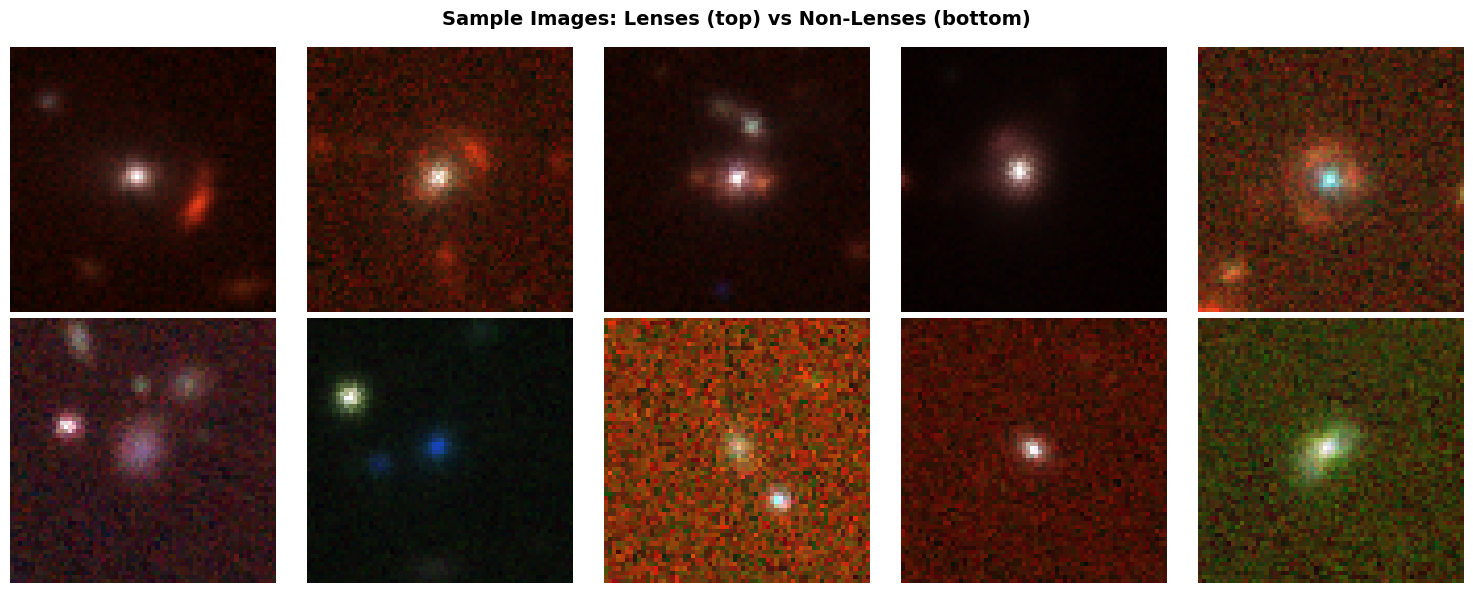

In [19]:
# Showing sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images: Lenses (top) vs Non-Lenses (bottom)', fontsize=14, fontweight='bold')

# Lenses
for col, idx in enumerate(np.random.choice(len(train_lens_paths), 5, replace=False)):
    img = np.load(train_lens_paths[idx])
    # (3, 64, 64) -> (64, 64, 3) for display, normalize to [0,1]
    img_display = np.transpose(img, (1, 2, 0))
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
    axes[0, col].imshow(img_display)
    if col == 0: axes[0, col].set_ylabel('LENS', fontsize=12, fontweight='bold')
    axes[0, col].axis('off')

# Non-lenses
for col, idx in enumerate(np.random.choice(len(train_nonlens_paths), 5, replace=False)):
    img = np.load(train_nonlens_paths[idx])
    img_display = np.transpose(img, (1, 2, 0))
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
    axes[1, col].imshow(img_display)
    if col == 0: axes[1, col].set_ylabel('NON-LENS', fontsize=12, fontweight='bold')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images_lens_finding.png', dpi=150, bbox_inches='tight')
plt.show()

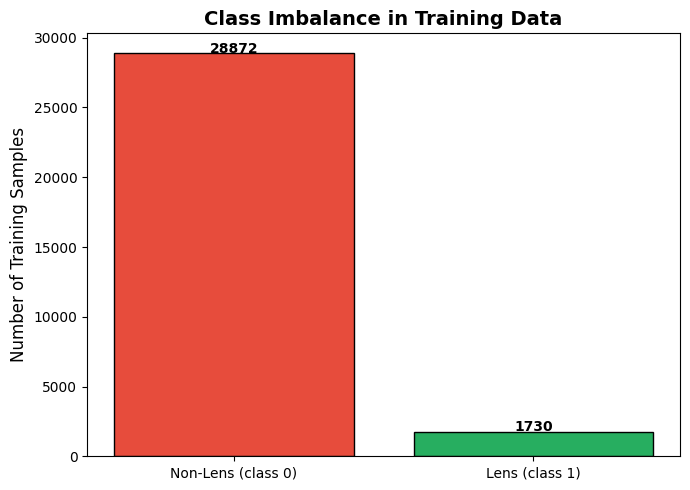

Imbalance ratio: 1 lens for every 17 non-lenses
This is extreme imbalance -- we need weighted loss and careful threshold tuning.


In [20]:
# Visualise the class imbalance
fig, ax = plt.subplots(figsize=(7, 5))
counts = [len(train_nonlens_paths), len(train_lens_paths)]
bars = ax.bar(['Non-Lens (class 0)', 'Lens (class 1)'], counts,
              color=['#e74c3c', '#27ae60'], edgecolor='black')
ax.set_ylabel('Number of Training Samples', fontsize=12)
ax.set_title('Class Imbalance in Training Data', fontsize=14, fontweight='bold')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{c}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = len(train_nonlens_paths) / max(len(train_lens_paths), 1)
print(f'Imbalance ratio: 1 lens for every {ratio:.0f} non-lenses')
print('This is extreme imbalance -- we need weighted loss and careful threshold tuning.')

---
## Step 3: Dataset and DataLoaders

Since the images are already 3-channel `(3, 64, 64)`, they map directly to what ResNet expects -- no channel replication needed this time.

For augmentation, I apply heavier augmentation to make the model more robust, especially since the lens class is so small. Rotations and flips are physically motivated by the symmetry of gravitational lensing.

In [21]:
IMG_SIZE = 64  # images are 64x64

class LensDataset(Dataset):
    """
    Lazy-loading dataset for lens finding.
    Loads each image from disk on demand to save RAM.
    Images are already (3, 64, 64) so no channel manipulation needed.
    """
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = np.load(self.file_paths[idx]).astype(np.float32)
        label = self.labels[idx]

        # Ensure (C, H, W) format
        if img.ndim == 2:
            img = img[np.newaxis, :, :]
        elif img.ndim == 3 and img.shape[-1] in [1, 3]:
            img = np.transpose(img, (2, 0, 1))

        img = torch.from_numpy(img)

        # If single channel, replicate to 3
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        if self.transform:
            img = self.transform(img)

        return img, label

In [22]:
# Augmentation: heavier for training since the lens class is tiny
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Shuffle training paths and labels together
shuffle_idx = np.random.permutation(len(train_paths))
train_paths_shuffled = train_paths[shuffle_idx]
train_labels_shuffled = train_labels[shuffle_idx]

BATCH_SIZE = 64

train_dataset = LensDataset(train_paths_shuffled, train_labels_shuffled, transform=train_transform)
test_dataset  = LensDataset(test_paths, test_labels, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Sanity check
b, l = next(iter(train_loader))
print(f'Batch shape: {b.shape}')
print(f'Labels: {l[:15].tolist()}')
print(f'Pixel range: [{b.min():.3f}, {b.max():.3f}]')

Batch shape: torch.Size([64, 3, 64, 64])
Labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
Pixel range: [-1.000, 1.000]


---
## Step 4: Build the Model

ResNet-18 with a 2-class output (lens vs non-lens). I compute class weights to handle the imbalance -- the loss function will penalize mistakes on the rare lens class much more heavily than mistakes on non-lenses.

In [23]:
# Build model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),   # slightly higher dropout for imbalanced data
    nn.Linear(num_features, 2)
)
model = model.to(device)

print(f'Model: ResNet-18 -> Dropout(0.4) -> 2 classes')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# Compute class weights: inversely proportional to class frequency
# This makes the model pay much more attention to the rare lens class
n_nonlens = len(train_nonlens_paths)
n_lens = len(train_lens_paths)
n_total = n_nonlens + n_lens

weight_nonlens = n_total / (2.0 * n_nonlens)
weight_lens = n_total / (2.0 * n_lens)
class_weights = torch.tensor([weight_nonlens, weight_lens], dtype=torch.float32).to(device)

print(f'\nClass weights:')
print(f'  Non-lens (0): {weight_nonlens:.4f}')
print(f'  Lens (1):     {weight_lens:.4f}')
print(f'  The lens class gets {weight_lens/weight_nonlens:.1f}x more weight in the loss.')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


Model: ResNet-18 -> Dropout(0.4) -> 2 classes
Parameters: 11,177,538

Class weights:
  Non-lens (0): 0.5300
  Lens (1):     8.8445
  The lens class gets 16.7x more weight in the loss.


---
## Step 5: Train the Model

In [24]:
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4

# Weighted CrossEntropyLoss to handle class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

train_losses, train_accs = [], []
test_losses, test_accs = [], []
best_auc = 0.0

print(f'Training for {NUM_EPOCHS} epochs with weighted loss...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Test Loss":>10} | {"Test Acc":>9} | {"LR":>10}')
print('-' * 70)

for epoch in range(NUM_EPOCHS):

    #  Training
    model.train()
    rl, cor, tot = 0.0, 0, 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device).long()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        rl += loss.item() * inputs.size(0)
        cor += outputs.argmax(1).eq(targets).sum().item()
        tot += targets.size(0)
    tr_loss, tr_acc = rl / tot, 100.0 * cor / tot
    train_losses.append(tr_loss); train_accs.append(tr_acc)

    #  Evaluation
    model.eval()
    rl, cor, tot = 0.0, 0, 0
    epoch_probs, epoch_labels = [], []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device).long()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            rl += loss.item() * inputs.size(0)
            cor += outputs.argmax(1).eq(targets).sum().item()
            tot += targets.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            epoch_probs.extend(probs)
            epoch_labels.extend(targets.cpu().numpy())

    te_loss, te_acc = rl / tot, 100.0 * cor / tot
    test_losses.append(te_loss); test_accs.append(te_acc)
    scheduler.step(te_loss)

    # Save best model based on AUC (better metric than accuracy for imbalanced data)
    epoch_auc = roc_auc_score(epoch_labels, epoch_probs)
    if epoch_auc > best_auc:
        best_auc = epoch_auc
        torch.save(model.state_dict(), 'best_model_lens.pth')

    lr = optimizer.param_groups[0]['lr']
    print(f'{epoch+1:>4}/{NUM_EPOCHS} | {tr_loss:>10.4f} | {tr_acc:>8.2f}% | '
          f'{te_loss:>10.4f} | {te_acc:>8.2f}% | {lr:>10.6f}  AUC={epoch_auc:.4f}')

print(f'\nDone! Best test AUC: {best_auc:.4f}')

Training for 20 epochs with weighted loss...

 Epoch | Train Loss | Train Acc |  Test Loss |  Test Acc |         LR
----------------------------------------------------------------------
   1/20 |     0.2962 |    87.18% |     0.0988 |    96.49% |   0.000100  AUC=0.9667
   2/20 |     0.1891 |    93.45% |     0.2196 |    91.05% |   0.000100  AUC=0.9772
   3/20 |     0.1689 |    93.74% |     0.1336 |    94.66% |   0.000100  AUC=0.9767
   4/20 |     0.1583 |    94.48% |     0.1164 |    95.23% |   0.000100  AUC=0.9795
   5/20 |     0.1500 |    94.35% |     0.1976 |    91.09% |   0.000050  AUC=0.9785
   6/20 |     0.1335 |    94.93% |     0.1446 |    94.26% |   0.000050  AUC=0.9804
   7/20 |     0.1241 |    95.25% |     0.0783 |    97.14% |   0.000050  AUC=0.9815
   8/20 |     0.1222 |    95.47% |     0.1074 |    96.13% |   0.000050  AUC=0.9856
   9/20 |     0.1186 |    95.57% |     0.0783 |    97.18% |   0.000050  AUC=0.9862
  10/20 |     0.1099 |    95.93% |     0.0715 |    97.48% |   0.00

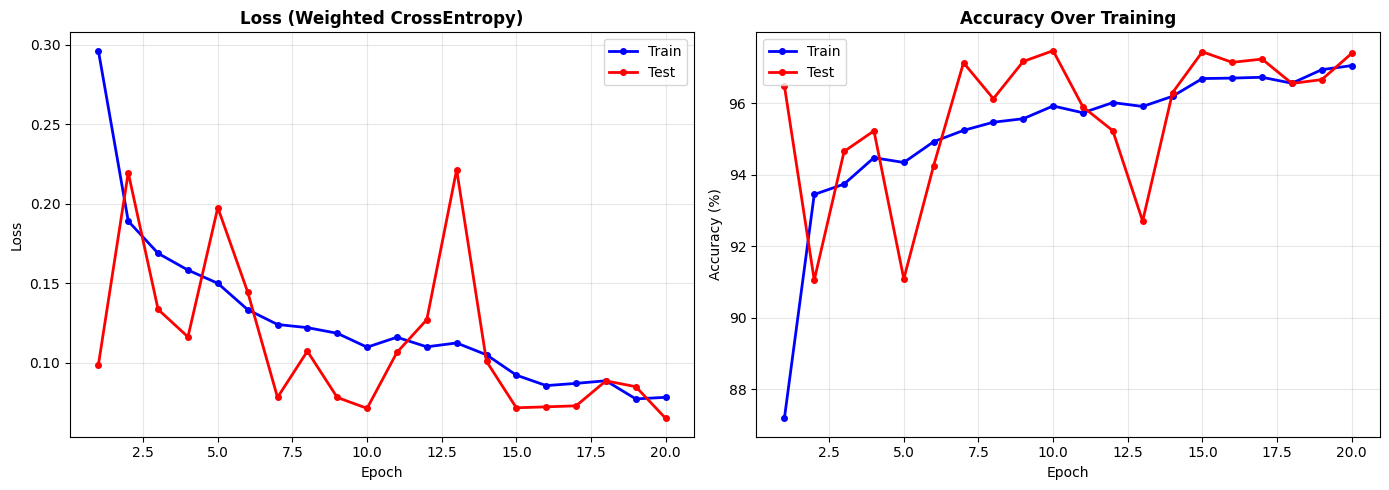

In [25]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
er = range(1, NUM_EPOCHS + 1)

ax1.plot(er, train_losses, 'b-o', label='Train', lw=2, ms=4)
ax1.plot(er, test_losses, 'r-o', label='Test', lw=2, ms=4)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss (Weighted CrossEntropy)', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(er, train_accs, 'b-o', label='Train', lw=2, ms=4)
ax2.plot(er, test_accs, 'r-o', label='Test', lw=2, ms=4)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Over Training', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_lens.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 6: Evaluation -- ROC Curve, AUC, and Threshold Optimization

For imbalanced data, accuracy is misleading (you could get 99% accuracy by just predicting "non-lens" every time). The real metrics that matter are:
- **AUC** -- measures the model's ability to rank lenses above non-lenses
- **Recall at low FPR** -- how many real lenses we find while keeping false positives manageable
- **Optimized F1 threshold** -- instead of the default 0.5, we find the probability threshold that maximizes F1-score

In [26]:
# Loading best model and run full evaluation
model.load_state_dict(torch.load('best_model_lens.pth'))
model.eval()
print('Best model loaded (selected by AUC).\n')

all_probs, all_preds, all_true = [], [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()  # probability of being a lens
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(targets.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_true = np.array(all_true)

print(f'Evaluated {len(all_true)} test images.')
print(f'  Actual lenses: {np.sum(all_true == 1)}')
print(f'  Actual non-lenses: {np.sum(all_true == 0)}')

Best model loaded (selected by AUC).

Evaluated 19650 test images.
  Actual lenses: 195
  Actual non-lenses: 19455


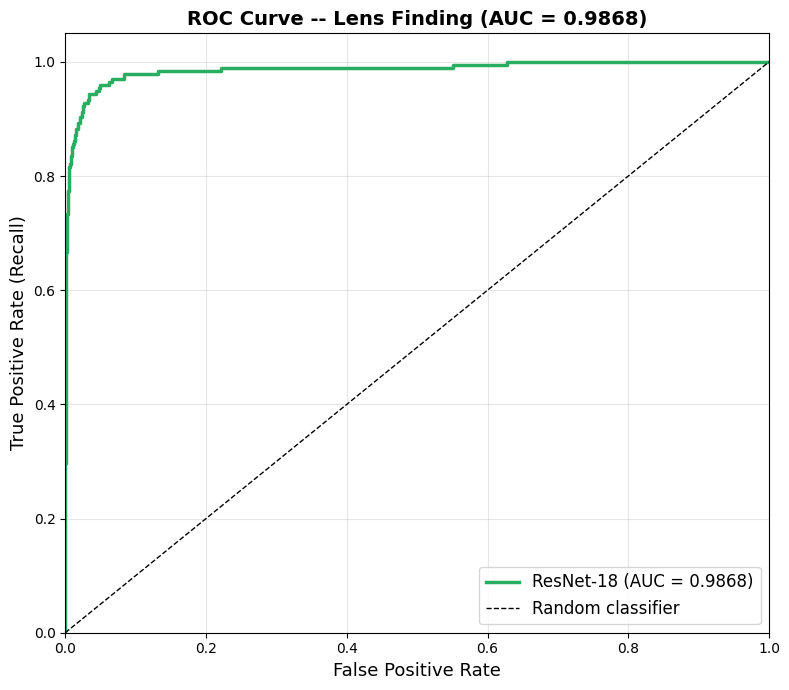


AUC Score: 0.9868
Recall at FPR=0.01: 0.8462 (i.e., we find 84.6% of real lenses with only 1% false positives)


In [27]:

# ROC CURVE AND AUC SCORE


fpr, tpr, thresholds = roc_curve(all_true, all_probs)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color='#27ae60', linewidth=2.5,
        label=f'ResNet-18 (AUC = {roc_auc_val:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=13)
ax.set_title(f'ROC Curve -- Lens Finding (AUC = {roc_auc_val:.4f})',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_lens_finding.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAUC Score: {roc_auc_val:.4f}')

# What is the recall at FPR = 0.01? (important for lens finding)
idx_fpr_01 = np.searchsorted(fpr, 0.01)
recall_at_fpr01 = tpr[min(idx_fpr_01, len(tpr)-1)]
print(f'Recall at FPR=0.01: {recall_at_fpr01:.4f} (i.e., we find {recall_at_fpr01*100:.1f}% of real lenses with only 1% false positives)')

In [28]:

# THRESHOLD OPTIMIZATION
# Instead of the default 0.5
# maximizes F1-score on the test set


precision_arr, recall_arr, thresh_arr = precision_recall_curve(all_true, all_probs)

# Compute F1 for each threshold
f1_scores = 2 * (precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-8)
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresh_arr[min(best_f1_idx, len(thresh_arr)-1)]
best_f1 = f1_scores[best_f1_idx]

print(f'Optimal threshold: {best_threshold:.4f}')
print(f'F1-score at optimal threshold: {best_f1:.4f}')
print(f'(Default 0.5 threshold F1: {f1_score(all_true, (all_probs >= 0.5).astype(int)):.4f})')

# Applying optimal threshold
optimized_preds = (all_probs >= best_threshold).astype(int)

Optimal threshold: 0.9745
F1-score at optimal threshold: 0.7324
(Default 0.5 threshold F1: 0.4192)


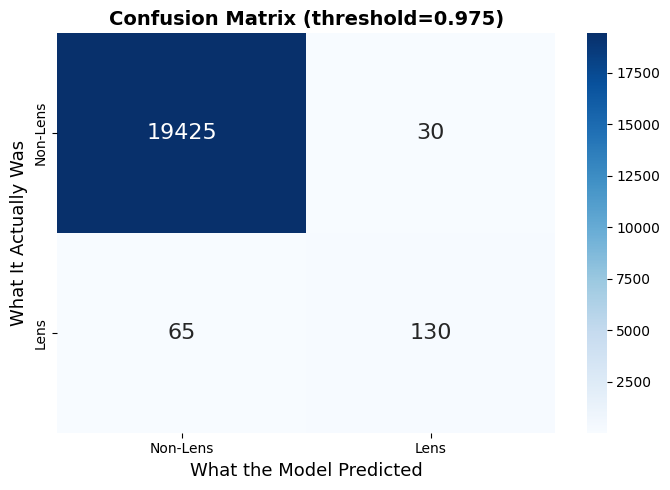

In [29]:
# Confusion matrix with the optimized threshold
cm = confusion_matrix(all_true, optimized_preds)
CLASS_NAMES_BIN = ['Non-Lens', 'Lens']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES_BIN, yticklabels=CLASS_NAMES_BIN,
            annot_kws={'size': 16}, ax=ax)
ax.set_xlabel('What the Model Predicted', fontsize=13)
ax.set_ylabel('What It Actually Was', fontsize=13)
ax.set_title(f'Confusion Matrix (threshold={best_threshold:.3f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_lens.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Full classification report
print(f'===== CLASSIFICATION REPORT (threshold={best_threshold:.3f}) =====\n')
print(classification_report(all_true, optimized_preds,
                            target_names=CLASS_NAMES_BIN, digits=4))

print(f'\n===== KEY METRICS =====')
print(f'  AUC Score:                {roc_auc_val:.4f}')
print(f'  Best F1 Score:            {best_f1:.4f}')
print(f'  Optimal Threshold:        {best_threshold:.4f}')
print(f'  Recall at FPR=0.01:       {recall_at_fpr01:.4f}')
print(f'========================')

===== CLASSIFICATION REPORT (threshold=0.975) =====

              precision    recall  f1-score   support

    Non-Lens     0.9967    0.9985    0.9976     19455
        Lens     0.8125    0.6667    0.7324       195

    accuracy                         0.9952     19650
   macro avg     0.9046    0.8326    0.8650     19650
weighted avg     0.9948    0.9952    0.9949     19650


===== KEY METRICS =====
  AUC Score:                0.9868
  Best F1 Score:            0.7324
  Optimal Threshold:        0.9745
  Recall at FPR=0.01:       0.8462


---
## Step 7: Save and Download

In [31]:
torch.save(model.state_dict(), 'resnet18_lens_finder.pth')

save_dir = '/content/drive/MyDrive/GSoC2026_DeepLense_Tests'
os.makedirs(save_dir, exist_ok=True)

for f in ['resnet18_lens_finder.pth', 'best_model_lens.pth',
          'roc_curve_lens_finding.png', 'confusion_matrix_lens.png',
          'training_curves_lens.png', 'sample_images_lens_finding.png',
          'class_imbalance.png']:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(save_dir, f))
        print(f'  Saved: {f}')

print(f'\nAll files saved to: {save_dir}')

  Saved: resnet18_lens_finder.pth
  Saved: best_model_lens.pth
  Saved: roc_curve_lens_finding.png
  Saved: confusion_matrix_lens.png
  Saved: training_curves_lens.png
  Saved: sample_images_lens_finding.png
  Saved: class_imbalance.png

All files saved to: /content/drive/MyDrive/GSoC2026_DeepLense_Tests


In [32]:
from google.colab import files
for f in ['roc_curve_lens_finding.png', 'confusion_matrix_lens.png',
          'training_curves_lens.png', 'sample_images_lens_finding.png']:
    if os.path.exists(f): files.download(f)
print('Check your browser downloads.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Check your browser downloads.


---
## Summary and Discussion

### Configuration

| Setting | Value |
|---------|-------|
| Model | ResNet-18 (ImageNet pretrained, fine-tuned) |
| Task | Binary classification (lens vs non-lens) |
| Input | 3-channel images (3 astronomical filters), 64x64 pixels |
| Train/Test split | As provided (train_lenses + train_nonlenses / test_lenses + test_nonlenses) |
| Augmentation | Flips, 180-degree rotations, color jitter |
| Class imbalance handling | Weighted CrossEntropyLoss (inverse frequency weighting) |
| Optimizer | Adam (lr=0.0001, weight_decay=0.0001) |
| Scheduler | ReduceLROnPlateau |
| Model selection | Best test AUC (not accuracy) |
| Threshold | Optimized for maximum F1-score |
| Epochs | 20 |

### Why weighted loss instead of oversampling?

With extreme class imbalance, a naive model would learn to predict "non-lens" every time and still get high accuracy. The weighted loss function addresses this by making mistakes on the rare lens class much more costly. I chose this over oversampling because it does not duplicate data (which can lead to overfitting on the minority class) and integrates naturally with gradient-based optimization.

### Why optimize the threshold?

The default classification threshold of 0.5 is rarely optimal for imbalanced problems. By sweeping across all possible thresholds and selecting the one that maximizes F1-score, we get a better trade-off between precision (not crying wolf too often) and recall (actually finding the lenses). In real lens surveys, this threshold would be tuned based on the cost of human expert time for visual inspection of candidates.

### Why save best model by AUC instead of accuracy?

AUC measures the model's ability to rank positive examples (lenses) above negative examples (non-lenses) across all possible thresholds. This is a much more informative metric than accuracy for imbalanced datasets, because accuracy can be artificially high even if the model never detects a single lens.

### Connection to my proposal

This test directly mirrors the DEEPLENSE6 project I proposed. The techniques used here -- weighted loss, threshold optimization, domain-aware augmentation -- are the same strategies outlined in my proposal for applying lens finding algorithms to real HSC-SSP survey data.